In [35]:
#julia version:1.11.6
include("Stability.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using PyCall
using BSplineKit

In [36]:
function eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
    sigma = 0.72
    # Keep the existing -G convention used by the stability equations.
    cof = CRC_STA.Spatial_mode_BEK(F,-G,H,T,sigma,N_cheb,D,D2,R)
    A0_raw,A1_raw,A2_raw = CRC_STA.assemble_mat(cof :: CRC_STA.COF,D,D2,be,omega,R)
    A0,A1,A2 = CRC_STA.boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2])
    sigma_key = Symbol("\u03c3")
    kwargs = NamedTuple{(sigma_key, :neigs, :maxit, :tol)}((c, num, 1000, 1e-8))
    eigval,eigvec = iar(nep; kwargs...)
    # iar ordering can change under tiny parameter changes; sort by shift distance.
    order = sortperm(abs.(eigval .- c))
    return eigval[order], eigvec[:,order]
end

function eigsol_near(F,G,H,T,R,omega,be,N_cheb,D,D2; alpha_ref=0.384+0im, neigs=2)
    vals, vecs = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,alpha_ref,neigs)
    idx = argmin(abs.(vals .- alpha_ref))
    return vals[idx], vals
end


eigsol_near (generic function with 1 method)

In [37]:
function interp(u0,v0,w0,T0,x,N)
    F = zeros(N+1)
    G = zeros(N+1)
    H = zeros(N+1)
    T = zeros(N+1)

    z = range(0, 20, 2000)

    itu = BSplineKit.interpolate(z, u0, BSplineOrder(4))
    itv = BSplineKit.interpolate(z, v0, BSplineOrder(4))
    itw = BSplineKit.interpolate(z, w0, BSplineOrder(4))
    itt = BSplineKit.interpolate(z, T0, BSplineOrder(4))

    for i in 1:N+1
        F[i] = itu(x[i])
        G[i] = itv(x[i])
        H[i] = itw(x[i])
        T[i] = itt(x[i])
    end

    return F, G, H, T
end

interp (generic function with 1 method)

In [38]:
Tw = 1.1
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)

([0.0, 0.010005002501250625, 0.02001000500250125, 0.030015007503751877, 0.0400200100050025, 0.05002501250625312, 0.060030015007503754, 0.07003501750875438, 0.080040020010005, 0.09004502251125562  …  19.909954977488745, 19.919959979989994, 19.929964982491246, 19.939969984992494, 19.949974987493746, 19.959979989995, 19.969984992496247, 19.9799899949975, 19.989994997498748, 20.0], [7.598392701516869e-24, -5.691190122123911e-5, -0.00022619678481613158, -0.0005056873449415697, -0.0008932520574212161, -0.001386777091194541, -0.0019841839145457963, -0.002683411449020372, -0.003482433423240102, -0.004379240775842994  …  -1.0898391855498, -1.089839185687285, -1.0898391858079384, -1.0898391859119383, -1.0898391859994605, -1.0898391860706818, -1.0898391861257777, -1.0898391861649197, -1.08983918618828, -1.0898391861960288], [0.0, 0.005670218682521037, 0.011231678239564759, 0.016685723765755313, 0.022033688460607406, 0.027276899540097935, 0.03241667208746254, 0.03745431508928348, 0.042391125186025

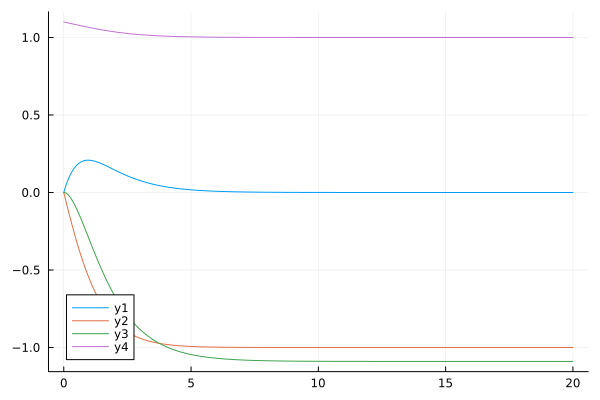

In [39]:
plot(z,F)
plot!(z,-G)
plot!(z,H)
plot!(z,T)

In [33]:
R = 285.365
omega = 0.0
be = 0.07759
Tw = 1.0
alpha_ref = 0.384 + 0im
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 99
c_ini = 0.3
num = 3
DM,D2M,x = CRC_STA.cheb_points(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
val,vec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c_ini,num)

(ComplexF64[0.3850520455353411 + 0.0003461320725931231im, 0.2270828040242134 + 0.052670571013073875im, 0.24569008561047403 + 0.10949514962538992im], ComplexF64[-0.00010078605794880626 - 0.0001958454424354232im -0.000171056634065631 - 2.4032902883175562e-5im -6.912200740749087e-6 + 4.4385386658459675e-5im; -0.00040309989515626907 - 0.000779871457457611im -0.0006828557824409119 - 9.494516911799688e-5im -2.9007492062404767e-5 + 0.00018009019454758978im; … ; 1.740685466558207e-14 + 8.96497618595065e-15im 3.0562821208209183e-12 + 1.1071832185174083e-12im -5.753683025419656e-10 - 1.3798370165581224e-9im; -3.0006716897207064e-14 - 1.3395520110850698e-14im -4.774879660201586e-12 - 1.6580772333667699e-12im 8.996681058095573e-10 + 2.2277318598843433e-9im])

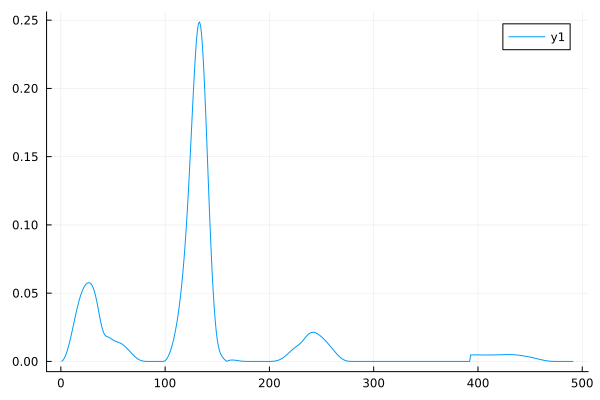

In [34]:
plot(abs.(vec[:,1]))

In [28]:
R_ini = 500
omega = 0.0
be_ini = 0.04
c_ini = 0.1
Tw = 1.01
num = 2
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 69
DM,D2M,x = CRC_STA.cheb_points(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
cur(Tw,omega,R_ini,c_ini,be_ini,num)

InterruptException: InterruptException:

In [24]:
function cur(Tw,omega,R_ini,c_ini,be_ini,num)
    be_scan_step = 0.0005
    beta_step = 0.008
    neigs_track = max(num, 2)

    pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
    bone = pyimport("Bone")
    z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
    N_cheb = 99
    DM,D2M,x = CRC_STA.cheb_points(N_cheb)
    F,G,H,T = interp(F,G,H,T,x,N_cheb)

    pick_mode(vals, alpha_ref) = vals[argmin(abs.(vals .- alpha_ref))]

    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    writedlm("output.dat", initial)
    writedlm("output_eig.dat", initial)

    eigval_ori,eigvec = eigsol(F,G,H,T,R_ini,omega,be_ini,N_cheb,DM,D2M,c_ini,neigs_track)
    alpha_last = pick_mode(eigval_ori, complex(c_ini, 0.0))
    open("output_eig.dat", "a") do io
        write(io,"be=$be_ini,alpha=$alpha_last,eig=$eigval_ori\n")
    end

    if abs(imag(alpha_last)) < 3e-5
        initial = [omega R_ini be_ini real(alpha_last) imag(alpha_last) real(alpha_last) imag(alpha_last)]
    else
        scan_dir = imag(alpha_last) > 0 ? 1 : -1
        be_stop = scan_dir > 0 ? 0.5 : -0.5
        be_last = be_ini

        for be = (be_ini + scan_dir*be_scan_step) : (scan_dir*be_scan_step) : be_stop
            eigval,eigvec = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,DM,D2M,alpha_last,neigs_track)
            alpha_now = pick_mode(eigval, alpha_last)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,alpha=$alpha_now,eig=$eigval\n")
            end

            if imag(alpha_last) * imag(alpha_now) < 0 || abs(imag(alpha_now)) < 3e-5
                initial = [omega R_ini be real(alpha_now) imag(alpha_now) real(alpha_now) imag(alpha_now)]
                break
            end

            be_last = be
            alpha_last = alpha_now
        end
    end

    if isempty(initial)
        error("No neutral crossing found from beta=$(be_ini) at R=$(R_ini). Try another R_ini/c_ini or a wider initial search.")
    end

    total = initial
    be = initial[3] + beta_step
    boundlen = 3

    while true
        c = complex(total[end,4], total[end,5])
        eigval,eigvec = eigsol(F,G,H,T,total[end,2],omega,be,N_cheb,DM,D2M,c,neigs_track)
        alpha_mid = pick_mode(eigval, c)
        eigval_1,eigvec = eigsol(F,G,H,T,total[end,2],omega,be-0.001,N_cheb,DM,D2M,c,neigs_track)
        eigval_2,eigvec = eigsol(F,G,H,T,total[end,2],omega,be+0.001,N_cheb,DM,D2M,c,neigs_track)
        alpha_1 = pick_mode(eigval_1, c)
        alpha_2 = pick_mode(eigval_2, c)
        num = 1

        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <= 2
            R_step = 0.25
        else
            R_step = 1
        end

        if (imag(alpha_1) < 0 && imag(alpha_2) > 0) || (imag(alpha_1) > 0 && imag(alpha_2) > 0)
            mode = 1
        elseif (imag(alpha_1) > 0 && imag(alpha_2) < 0) || (imag(alpha_1) < 0 && imag(alpha_2) < 0)
            mode = 2
        else
            mode = imag(alpha_mid) > 0 ? 2 : 1
        end

        if mode == 1
            alpha_ref = c
            for R = total[end,2] : R_step : 700
                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,alpha_ref,neigs_track)
                alpha_now = pick_mode(eigval, alpha_ref)
                alpha_ref = alpha_now

                tempvec_1 = [tempvec_1; [omega R be real(alpha_now) imag(alpha_now) real(alpha_now) imag(alpha_now)]]
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,alpha=$alpha_now,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1,5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5]) < 0.001) || abs(tempvec_1[end,5]) < 3e-5
                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]
                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100
                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]
                    break
                end
            end
        end

        if mode == 2
            alpha_ref = c
            for R = total[end,2]: -R_step : 0
                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,alpha_ref,neigs_track)
                alpha_now = pick_mode(eigval, alpha_ref)
                alpha_ref = alpha_now

                tempvec_1 = [tempvec_1; [omega R be real(alpha_now) imag(alpha_now) real(alpha_now) imag(alpha_now)]]
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,alpha=$alpha_now,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1,5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5]) < 0.001) || abs(tempvec_1[end,5]) < 3e-5
                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]
                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100
                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]
                    break
                end
            end
        end

        if mode == 1
            alpha_ref = c
            for R = total[end,2]: R_step : 700
                if total[end,3] == be
                    break
                end

                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,alpha_ref,neigs_track)
                alpha_now = pick_mode(eigval, alpha_ref)
                alpha_ref = alpha_now

                tempvec_1 = [tempvec_1; [omega R be real(alpha_now) imag(alpha_now) real(alpha_now) imag(alpha_now)]]
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,alpha=$alpha_now,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1,5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5]) < 0.001) || abs(tempvec_1[end,5]) < 3e-5
                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]
                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100
                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]
                    break
                end
            end
        end

        be += beta_step
        filename = "ome=$(omega)_Tw=$(Tw).dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Tw=$(Tw)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end

        if total[end,2] > 500 && size(total,1) > 30
            break
        end
    end
end


cur (generic function with 1 method)